# TP2 - Etapa 2 en Google Colab: dataset, preprocesamiento, entrenamiento y comparacion de modelos

Notebook de trabajo de la Etapa 2: analisis del dataset, preprocesamiento, fine-tuning de
ResNet18 (Modelo A, obligatorio), CNN propia (Modelo B, opcional) y estudio comparativo.

El entrenamiento se realiza en Colab para aprovechar la GPU:
**Entorno de ejecucion -> Cambiar tipo de entorno de ejecucion -> GPU (T4)**.

Requisitos previos (en tu fork):
- `train_classifier`, `evaluate_classifier` y `extract_custom_embedding` implementadas
  en `src/lib/services/classifier_service.py` (esta notebook solo las orquesta).

Al finalizar:
- Descargar los checkpoints generados y colocarlos en `models/` de tu entorno local
  (la aplicacion los usa en las pestañas Etapa 1 y 2 del frontend).
- Publicarlos en un link de solo lectura publico para los docentes.
- Entregar esta notebook ejecutada, con sus salidas.

## Equipo
- Alumno 1 : Esteva Matias (E-1253/1)

## 1. Clonar el repositorio

Si tu fork es privado, genera un token de acceso (GitHub -> Settings -> Developer settings ->
Personal access tokens) y usalo en la URL, o sube un zip del proyecto a Colab/Drive.

In [1]:
# TO-DO: completar con la URL de tu fork.
# Repo privado: https://<TOKEN>@github.com/<usuario>/tuia-dog-recognition-app.git
# REPO_URL = "https://github.com/<usuario>/tuia-dog-recognition-app.git"

# !git clone $REPO_URL proyecto
# %cd proyecto

## 2. Instalar dependencias

Colab ya incluye torch, torchvision, opencv, numpy, scikit-learn y matplotlib;
solo se instala lo que falta.

In [2]:
# !pip install -q pydantic-settings python-dotenv kagglehub albumentations

## 3. Configuracion del entorno


In [3]:
from pathlib import Path
import sys
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import os
import torch
import pandas as pd
import seaborn as sns
from PIL import Image
import numpy as np
from torchvision import transforms
import random
from lib.bootstrap import build_classifier
import time
import matplotlib.pyplot as plt

os.environ["USE_PGVECTOR"] = "false"
# Ajusta aca cualquier otra variable (IMAGE_SIZE, EMBEDDING_DIM, paths, etc.)


from lib.config import settings

print("dataset_path:", settings.dataset_path)
print("GPU disponible:", torch.cuda.is_available())

dataset_path: data\dataset
GPU disponible: True


## 4. Descargar el dataset

In [ ]:
# !python scripts/download_dataset.py
# !ls data/dataset

## 5. Analisis del dataset

In [5]:
DATASET_ROOT = Path("data/dataset")

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "valid"
TEST_DIR = DATASET_ROOT / "test"

In [6]:
def crear_dataframe(split_dir, split_name):

    rows = []

    for breed_dir in sorted(split_dir.iterdir()):

        if not breed_dir.is_dir():
            continue

        breed = breed_dir.name

        for img_path in breed_dir.glob("*"):

            rows.append({
                "split": split_name,
                "breed": breed,
                "path": str(img_path)
            })

    return pd.DataFrame(rows)


train_df = crear_dataframe(TRAIN_DIR, "train")
val_df   = crear_dataframe(VAL_DIR, "val")
test_df  = crear_dataframe(TEST_DIR, "test")

df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True)

df.head()

,split,breed,path
0,train,Afghan,data\dataset\train\Afghan\001.jpg
1,train,Afghan,data\dataset\train\Afghan\002.jpg
2,train,Afghan,data\dataset\train\Afghan\003.jpg
3,train,Afghan,data\dataset\train\Afghan\004.jpg
4,train,Afghan,data\dataset\train\Afghan\005.jpg


In [7]:
print("Total imágenes:", len(df))
print("Cantidad de razas:", df["breed"].nunique())

print("\nTrain:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Total imágenes: 9346
Cantidad de razas: 70

Train: 7946
Validation: 700
Test: 700


In [ ]:
# !mv "data/dataset/valid/American  Spaniel" "data/dataset/valid/American Spaniel"

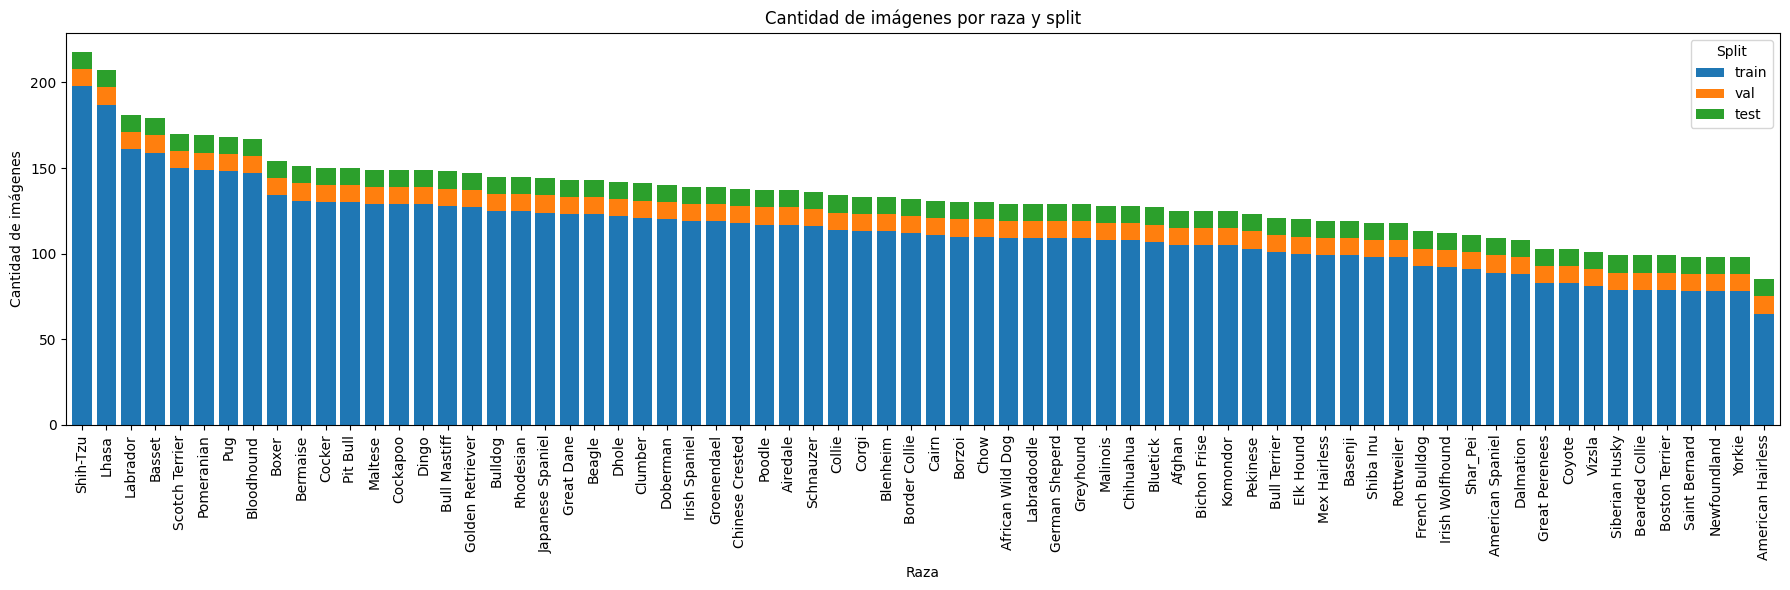

In [8]:
summary = pd.DataFrame({
    "train": train_df["breed"].value_counts(),
    "val": val_df["breed"].value_counts(),
    "test": test_df["breed"].value_counts()
}).fillna(0)

summary = summary.sort_index()

summary["total"] = summary.sum(axis=1)

summary = summary.sort_values(
    by="total",
    ascending=False
)

summary[["train", "val", "test"]].plot(
    kind="bar",
    stacked=True,
    figsize=(18, 6),
    width=0.8
)

plt.title("Cantidad de imágenes por raza y split")
plt.xlabel("Raza")
plt.ylabel("Cantidad de imágenes")

plt.legend(title="Split")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [9]:
sizes = []

for path in df["path"]:

    img = Image.open(path)

    sizes.append(img.size)

sizes_df = pd.DataFrame(
    sizes,
    columns=["width", "height"]
)

sizes_df.value_counts()

width  height
224    224       9346
Name: count, dtype: int64

El dataset cuenta con un total de 9346 imágenes distribuidas en 70 razas de perros. Todas las imágenes tienen una resolución de 224x224 píxeles.

Al analizar el gráfico de barras de se observa una distribución desbalanceada

Las razas mayoritarias como el Shih-Tzu o el Lhasa superan las 200 imágenes totales y las razas minoritarias (como el American Hairless o el Yorkie) apenas alcanzan entre 70 y 90 imágenes.

Este desbalance justifica el uso de técnicas de compensación durante el entrenamiento como el uso de un WeightedRandomSampler o la asignación de pesos a la función de pérdida (CrossEntropy) para evitar que el modelo se sesgue hacia las clases mayoritarias.

Definición de los Splits (Conjuntos de Datos)
La partición del dataset se realizó de la siguiente manera para asegurar un correcto entrenamiento y evaluación:

Entrenamiento (Train): 7946 imágenes (~85%). Utilizadas para el ajuste de pesos del modelo.

Validación (Val): 700 imágenes (~7.5%). Utilizadas para monitorear el desempeño por época, ajustar hiperparámetros y guardar el mejor checkpoint evitando el overfitting.

Prueba (Test): 700 imágenes (~7.5%). Conjunto reservado y nunca visto por el modelo hasta el final, utilizado para reportar las métricas de rendimiento reales (Accuracy, F1-Score, etc.).

Como se observa en el gráfico, los splits se extrajeron de manera estratificada, garantizando que haya proporción de imágenes de validación y prueba en absolutamente todas las 70 razas.

## 6. Preprocesamiento


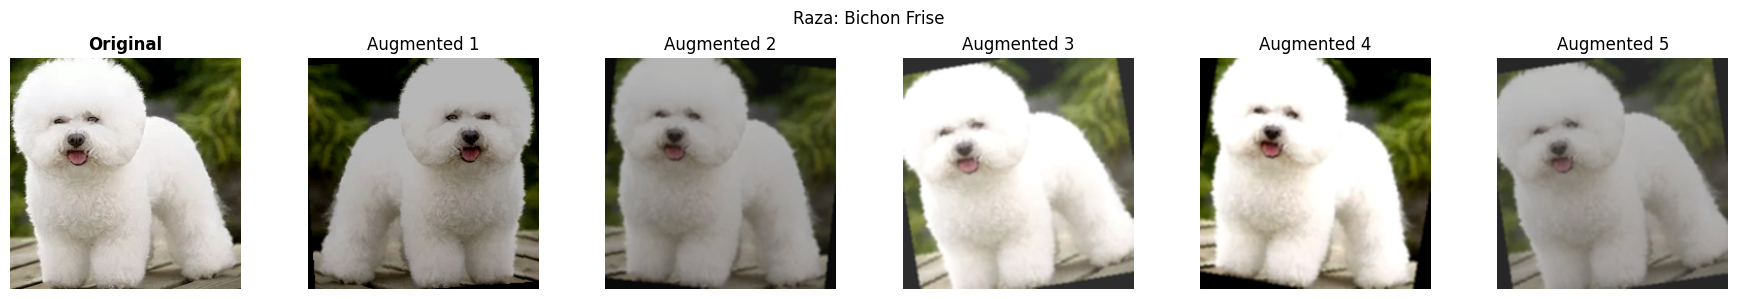

Transforms train: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=None, hue=None)
    GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Transforms val/test: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [10]:
# Transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Ejemplo visual
# Tomamos una imagen al azar del train para mostrar el efecto del augmentation

breeds   = sorted(os.listdir(settings.dataset_path / "train"))
breed    = random.choice(breeds)
img_path = random.choice(list((settings.dataset_path / "train" / breed).iterdir()))
original = Image.open(img_path).convert("RGB")

# Generar 5 versiones aumentadas
augment_only = transforms.Compose(train_transform.transforms[:-2])
augmented    = [augment_only(original) for _ in range(5)]

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
axes[0].imshow(original.resize((224, 224)))
axes[0].set_title("Original", fontweight="bold")
axes[0].axis("off")

for i, img in enumerate(augmented):
    axes[i + 1].imshow(img)
    axes[i + 1].set_title(f"Augmented {i+1}")
    axes[i + 1].axis("off")

fig.suptitle(f"Raza: {breed}", fontsize=12)
plt.tight_layout()
plt.show()

print("Transforms train:", train_transform)
print("\nTransforms val/test:", val_test_transform)

Para mejorar la robustez del modelo y evitar el sobreajuste se implementó un pipeline de transformaciones utilizando torchvision.transforms.

**Transformaciones Comunes (Train, Val, Test)**
Resize (224x224): Es la dimensión de entrada estándar requerida por ResNet18. Permite unificar el tensor de entrada y optimizar el costo computacional.

ToTensor: Convierte las imágenes (PIL) a tensores de PyTorch, cambiando el rango de píxeles de [0, 255] a [0.0, 1.0] y reordenando los canales a (C, H, W).

Normalize: Se utilizan los valores de media [0.485, 0.456, 0.406] y desviación estándar [0.229, 0.224, 0.225]. Estos son los estadísticos del dataset ImageNet. Al hacer Transfer Learning es necesario normalizar las imágenes con estos mismos valores.

**Transformaciones Exclusivas de Entrenamiento (Data Augmentation)**
Aplicadas de forma aleatoria para generar variabilidad artificial y forzar al modelo a aprender características invariantes:

RandomHorizontalFlip (p=0.5): Voltea la imagen horizontalmente con un 50% de probabilidad.

RandomRotation (15°): Rota la imagen aleatoriamente hasta 15 grados.

ColorJitter (brightness=0.3, contrast=0.3): Modifica el brillo y contraste. Enseña al modelo a no depender estrictamente de un color exacto haciéndolo robusto a fotos sobreexpuestas o subexpuestas.

GaussianBlur (kernel=3, sigma=0.1-2.0): Aplica un ligero desenfoque aleatorio.

## 7. Modelo A (obligatorio): fine-tuning de ResNet18

`train_classifier` debe guardar el checkpoint en `models/resnet18_finetuned.pth`
(o el nombre configurado en RESNET18_MODEL_NAME). Documentar los hiperparametros
utilizados (learning rate, batch size, epochs, optimizador, scheduler).

### Hiperparámetros — Modelo A (ResNet18 fine-tuned)

| Parámetro     | Valor                                  |
|---------------|----------------------------------------|
| Image size    | 224×224                                |
| Batch size    | 128                                    |
| Epochs        | 20                                     |
| Optimizador   | Adam (lr=3e-4)                         |
| Scheduler     | CosineAnnealingLR (T_max=20)           |
| Loss          | CrossEntropyLoss (ponderada por clase) |
| Augmentation  | flip, rotate, jitter, blur             |
| Balanceo      | WeightedRandomSampler + pesos en loss  |

In [9]:
inicio_a = time.perf_counter()

classifier_a = build_classifier(settings)
classifier_a.set_active_model("resnet18_finetuned")
classifier_a.train_classifier()

fin_a = time.perf_counter()
tiempo_a = fin_a - inicio_a

INFO:lib.services.classifier_service:Entrenando resnet18_finetuned en cuda
INFO:lib.services.classifier_service:Epoch 1/20 — train_loss=1.5711 train_acc=0.6548 val_loss=0.7384 val_acc=0.8200
INFO:lib.services.classifier_service: Checkpoint guardado (val_acc=0.8200)
INFO:lib.services.classifier_service:Epoch 2/20 — train_loss=0.4549 train_acc=0.8894 val_loss=0.3426 val_acc=0.9000
INFO:lib.services.classifier_service: Checkpoint guardado (val_acc=0.9000)
INFO:lib.services.classifier_service:Epoch 3/20 — train_loss=0.2788 train_acc=0.9323 val_loss=0.3267 val_acc=0.9129
INFO:lib.services.classifier_service: Checkpoint guardado (val_acc=0.9129)
INFO:lib.services.classifier_service:Epoch 4/20 — train_loss=0.2021 train_acc=0.9480 val_loss=0.2658 val_acc=0.9200
INFO:lib.services.classifier_service: Checkpoint guardado (val_acc=0.9200)
INFO:lib.services.classifier_service:Epoch 5/20 — train_loss=0.1690 train_acc=0.9544 val_loss=0.2814 val_acc=0.9086
INFO:lib.services.classifier_service:Epoch 6/

In [10]:
print(f'Tiempo ejecucion modelo A:  {tiempo_a/60:.2f} minutos')
metrics_a = classifier_a.evaluate_classifier()
metrics_a

Tiempo ejecucion modelo A:  11.53 minutos


INFO:lib.services.classifier_service:evaluate_classifier [resnet18_finetuned]: {'accuracy': 0.9543, 'precision': 0.9584, 'recall': 0.9543, 'specificity': 0.9993, 'f1': 0.9538}


{'accuracy': 0.9543,
 'precision': 0.9584,
 'recall': 0.9543,
 'specificity': 0.9993,
 'f1': 0.9538}

### Curvas de entrenamiento y matriz de confusion (Modelo A)

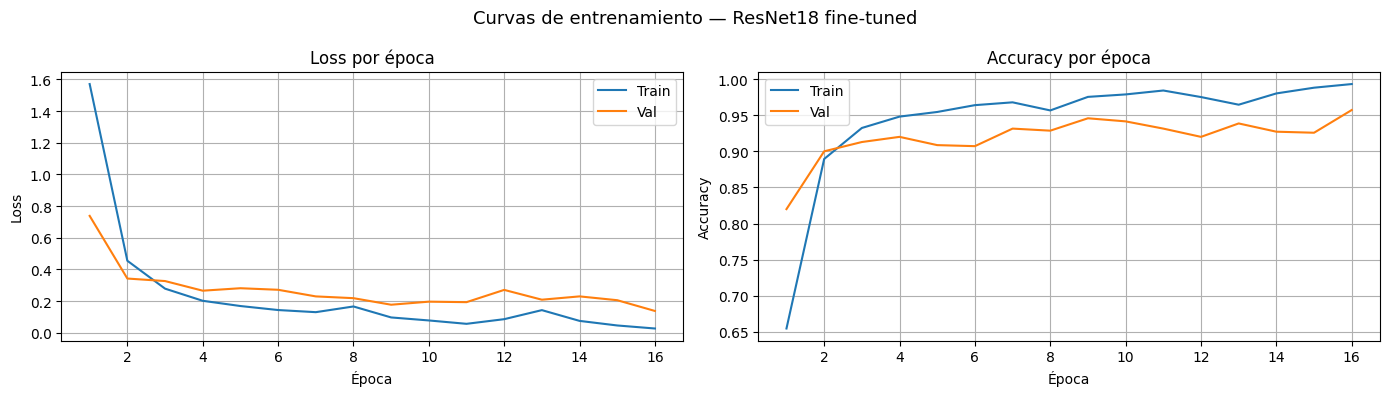

In [11]:
history_a = classifier_a.history
epochs  = range(1, len(history_a["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs, history_a["train_loss"], label="Train")
axes[0].plot(epochs, history_a["val_loss"],   label="Val")
axes[0].set_title("Loss por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history_a["train_acc"], label="Train")
axes[1].plot(epochs, history_a["val_acc"],   label="Val")
axes[1].set_title("Accuracy por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Curvas de entrenamiento — ResNet18 fine-tuned", fontsize=13)
plt.tight_layout()
plt.show()

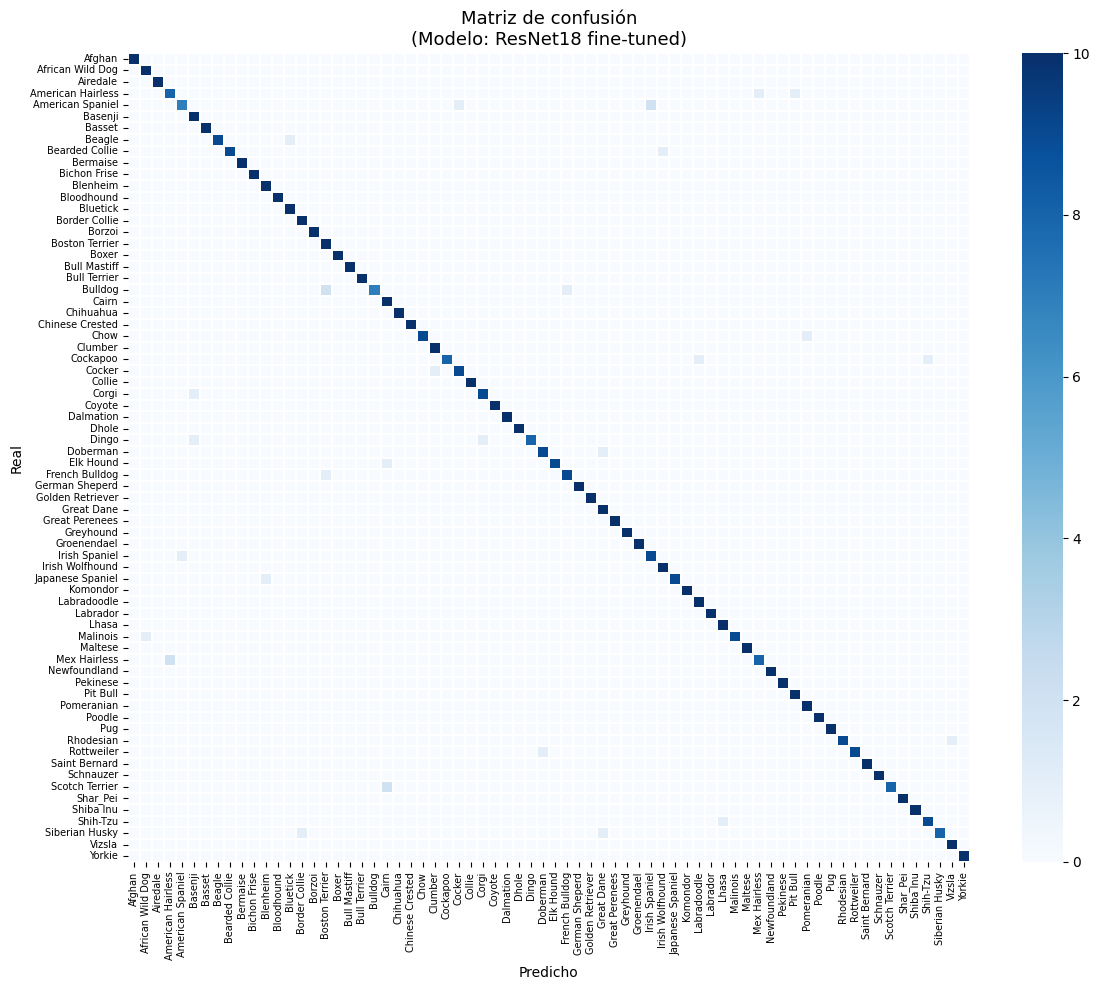

In [12]:
cm = classifier_a.confusion_matrix_
class_names = classifier_a.class_names_

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.3, cbar=True)

plt.title("Matriz de confusión\n(Modelo: ResNet18 fine-tuned)", fontsize=13)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)

plt.tight_layout()
plt.show()

## 8. Modelo B (opcional, recomendado): CNN propia

`train_classifier` con el modelo activo `cnn_custom` debe guardar el checkpoint en
`models/cnn_custom.pth` (o el nombre configurado en CNN_CUSTOM_MODEL_NAME).

### Hiperparámetros — Modelo B (CNN custom)

| Parámetro     | Valor                                  |
|---------------|----------------------------------------|
| Image size    | 224×224                                |
| Batch size    | 128                                    |
| Epochs        | 100                                    |
| Optimizador   | Adam (lr=3e-4)                         |
| Scheduler     | CosineAnnealingLR (T_max=100)          |
| Loss          | CrossEntropyLoss (ponderada por clase) |
| Augmentation  | flip, rotate, jitter, blur             |
| Balanceo      | WeightedRandomSampler + pesos en loss  |

In [4]:
inicio_b = time.perf_counter()

classifier_b = build_classifier(settings)
classifier_b.set_active_model("cnn_custom")
classifier_b.train_classifier()


fin_b = time.perf_counter()
tiempo_b = fin_b - inicio_b

INFO:lib.services.classifier_service:Entrenando cnn_custom en cuda
INFO:lib.services.classifier_service:Epoch 1/100 — train_loss=4.1100 train_acc=0.0477 val_loss=3.9574 val_acc=0.0500
INFO:lib.services.classifier_service: Checkpoint guardado (val_acc=0.0500)
INFO:lib.services.classifier_service:Epoch 2/100 — train_loss=3.8885 train_acc=0.0744 val_loss=3.7541 val_acc=0.0829
INFO:lib.services.classifier_service: Checkpoint guardado (val_acc=0.0829)
INFO:lib.services.classifier_service:Epoch 3/100 — train_loss=3.7374 train_acc=0.0834 val_loss=3.6594 val_acc=0.0871
INFO:lib.services.classifier_service: Checkpoint guardado (val_acc=0.0871)
INFO:lib.services.classifier_service:Epoch 4/100 — train_loss=3.5649 train_acc=0.1092 val_loss=4.1341 val_acc=0.0586
INFO:lib.services.classifier_service:Epoch 5/100 — train_loss=3.4646 train_acc=0.1222 val_loss=3.5240 val_acc=0.1143
INFO:lib.services.classifier_service: Checkpoint guardado (val_acc=0.1143)
INFO:lib.services.classifier_service:Epoch 6/100

In [6]:
print(f'Tiempo ejecucion modelo B: {tiempo_b/60:.2f} minutos')
metrics_b = classifier_b.evaluate_classifier()
metrics_b

Tiempo ejecucion modelo B: 102.58 minutos


INFO:lib.services.classifier_service:evaluate_classifier [cnn_custom]: {'accuracy': 0.8257, 'precision': 0.8443, 'recall': 0.8257, 'specificity': 0.9975, 'f1': 0.8252}


{'accuracy': 0.8257,
 'precision': 0.8443,
 'recall': 0.8257,
 'specificity': 0.9975,
 'f1': 0.8252}

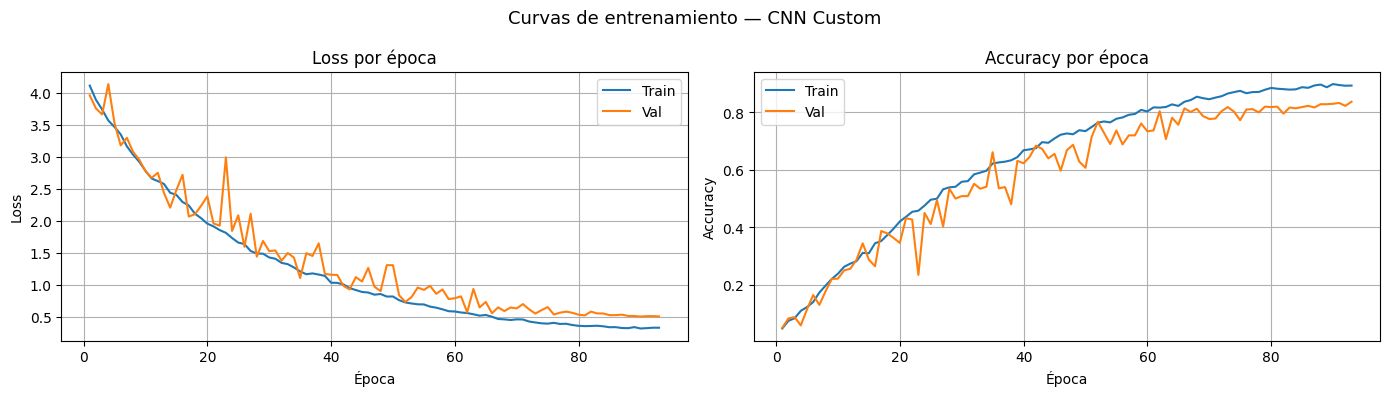

In [7]:
history_b = classifier_b.history
epochs  = range(1, len(history_b["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs, history_b["train_loss"], label="Train")
axes[0].plot(epochs, history_b["val_loss"],   label="Val")
axes[0].set_title("Loss por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history_b["train_acc"], label="Train")
axes[1].plot(epochs, history_b["val_acc"],   label="Val")
axes[1].set_title("Accuracy por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Curvas de entrenamiento — CNN Custom", fontsize=13)
plt.tight_layout()
plt.show()

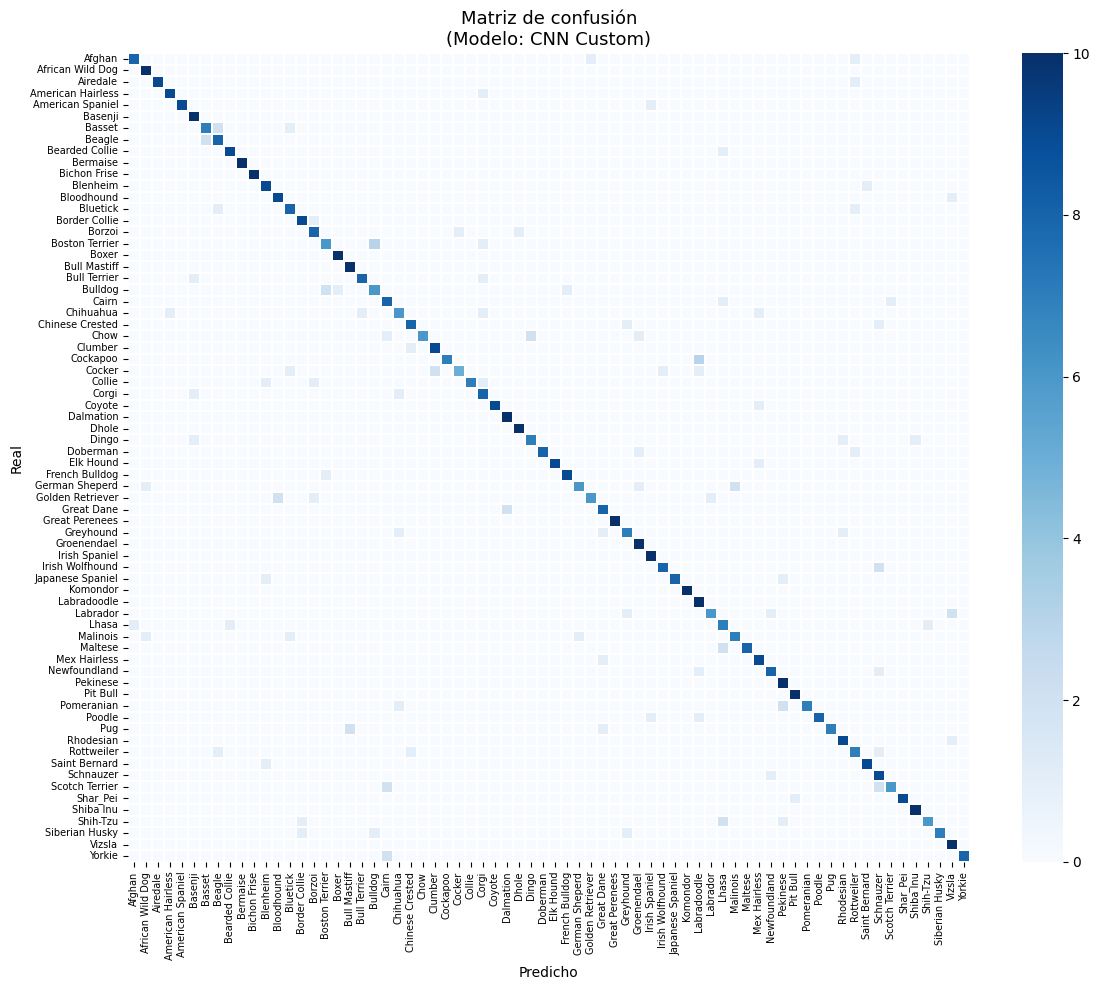

In [8]:
cm = classifier_b.confusion_matrix_
class_names = classifier_b.class_names_


plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.3, cbar=True)

plt.title("Matriz de confusión\n(Modelo: CNN Custom)", fontsize=13)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)

plt.tight_layout()
plt.show()

## 9. Estudio comparativo

- Comparar los modelos entrenados: accuracy, precision, recall, specificity, F1.
- Analizar las clases con peor desempeño (falsos positivos / falsos negativos).
- Discutir trade-offs (performance vs costo computacional).

In [ ]:
# Tabla comparativa de métricas

tiempo_a_min = int(tiempo_a / 60)
tiempo_b_min = int(tiempo_b / 60)

tabla = pd.DataFrame({
    "Métrica":       ["Accuracy", "Precision", "Recall", "Specificity", "F1-Score", "Tiempo entrenamiento (min)"],
    "ResNet18 (A)":  [metrics_a["accuracy"], metrics_a["precision"], metrics_a["recall"],
                      metrics_a["specificity"], metrics_a["f1"], tiempo_a_min],
    "CNN custom (B)": [metrics_b["accuracy"], metrics_b["precision"], metrics_b["recall"],
                       metrics_b["specificity"], metrics_b["f1"], tiempo_b_min],
})


display(tabla)

# Clases con peor desempeño /  Recall por clase para cada modelo
cm_a    = classifier_a.confusion_matrix_
cm_b    = classifier_b.confusion_matrix_
names_a = classifier_a.class_names_
names_b = classifier_b.class_names_

recall_a = cm_a.diagonal() / cm_a.sum(axis=1)
recall_b = cm_b.diagonal() / cm_b.sum(axis=1)

# Falsos positivos por clase
fp_a = cm_a.sum(axis=0) - cm_a.diagonal()
fp_b = cm_b.sum(axis=0) - cm_b.diagonal()

# Falsos negativos por clase
fn_a = cm_a.sum(axis=1) - cm_a.diagonal()
fn_b = cm_b.sum(axis=1) - cm_b.diagonal()

# Top 10 peores clases por recall (modelo A como referencia)
peor_idx = np.argsort(recall_a)[:10]

df_peor = pd.DataFrame({
    "Raza":              [names_a[i] for i in peor_idx],
    "Recall A":          [round(recall_a[i], 3) for i in peor_idx],
    "FP A":              [int(fp_a[i])           for i in peor_idx],
    "FN A":              [int(fn_a[i])            for i in peor_idx],
    "Recall B":          [round(recall_b[i], 3)  for i in peor_idx],
    "FP B":              [int(fp_b[i])            for i in peor_idx],
    "FN B":              [int(fn_b[i])            for i in peor_idx],
})
print("\nClases con peor recall:")
display(df_peor)


,Métrica,ResNet18 (A),CNN custom (B)
0,Accuracy,0.9543,0.8257
1,Precision,0.9584,0.8443
2,Recall,0.9543,0.8257
3,Specificity,0.9993,0.9975
4,F1-Score,0.9538,0.8252
5,Tiempo entrenamiento (min),11.0000,102.0000



Clases con peor recall:


,Raza,Recall A,FP A,FN A,Recall B,FP B,FN B
0,American Spaniel,0.7,1,3,0.9,0,1
1,Bulldog,0.7,0,3,0.6,4,4
2,Cockapoo,0.8,0,2,0.7,0,3
3,American Hairless,0.8,2,2,0.9,1,1
4,Mex Hairless,0.8,1,2,0.9,3,1
5,Scotch Terrier,0.8,0,2,0.6,1,4
6,Dingo,0.8,0,2,0.7,2,3
7,Siberian Husky,0.8,0,2,0.7,0,3
8,Corgi,0.9,1,1,0.8,5,2
9,Elk Hound,0.9,0,1,0.9,0,1


El peor recall del Modelo A es 0.7 (American Spaniel y Bulldog) lo que significa que en el peor caso el modelo identifica correctamente el 70% de las imágenes de esa raza.

Modelo A tiene recalls más altos y menos FP que el B en casi todas las clases problemáticas. Las confusiones que persisten en ambos modelos corresponden a razas que comparten características morfológicas reales, lo que sugiere que el límite no es el modelo sino la similitud intrínseca entre clases.

### Comparacion:

ResNet18 (Modelo A): Al utilizar Transfer Learning las capas convolucionales del modelo ya saben identificar bordes, texturas y formas complejas gracias a su entrenamiento previo en ImageNet. Al reentrenar solo la última capa el modelo logra métricas de Accuracy y F1-Score considerablemente más altas y sufre menos de sobreajuste ya que los pesos internos están congelados.

CNN Custom (Modelo B): Al estar diseñada desde cero la red debe aprender todas las características visuales de nuestro dataset de perros. Esto resulta en una pérdida de performance comparado con ResNet.

**Costo Computacional (Tiempo y Recursos)**

Tiempo de Entrenamiento: El tiempo de procesamiento por época casi no presenta diferencias entre ambos modelos. Sin embargo el costo total se evidencia en la convergencia: la CNN Custom necesita muchas más épocas porque tiene que aprender todo desde cero. En contraste, la ResNet18 logra un accuracy superior utilizando una quinta partede las épocas y volviendo el proceso más rápido y eficiente.

Costo de Inferencia: La ResNet18 es más pesada en memoria y cantidad de parámetros totales. La CNN Custom, dependiendo de la cantidad de filtros, podría ser marginalmente más ligera para inferir una sola imagen, aunque la diferencia en hardware moderno suele ser despreciable frente a la enorme ganancia de precisión de la ResNet.

**Trade-Off**
El modelo A entrega un rendimiento muy superior y requiere solo una fracción de las épocas para converger. El modelo B es un buen ejercicio para entender el diseño de arquitecturas desde cero, pero el alto costo en cantidad de iteraciones necesarias para igualar el aprendizaje base no justifica su uso frente a la eficiencia del transfer learning para esta tarea donde el problema a resolver no es tan especifico y ya existen modelos preentrenados con buenos rendimientos.

## 10. Descargar los checkpoints

Descargalos y colocalos en `models/` de tu entorno local para que la aplicacion los use
(pestañas Etapa 1 y 2 del frontend). Recorda publicarlos en un link de solo lectura publico.

### **Link carpeta con modelos**

https://drive.google.com/drive/folders/1NlYdaqGbPtmcyE4_-cuiI0UgKTYaMOyp?usp=sharing

In [ ]:
#!ls -lh models/

#try:
#    from google.colab import files
#
#    files.download(str(settings.model_path / settings.resnet18_model_name))
#    # files.download(str(settings.model_path / settings.cnn_custom_model_name))
#except ImportError:
#    print("Fuera de Colab: los checkpoints quedan en models/")